# Simple Squential Workflow

In [14]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [33]:
# State
class BMI_State(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float
    category: str

In [25]:
def calculate_bmi(State: BMI_State) -> BMI_State:
    State['bmi'] = State['weight_kg'] / (State['height_m'] ** 2)
    return State

In [34]:
def label_bmi(state: BMI_State) -> BMI_State:

    bmi = state['bmi']

    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"

    return state

In [35]:
# Create new Graph
graph = StateGraph(BMI_State)

# Add Node
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('label_fitnell', label_bmi)

# Draw Relationship
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'label_fitnell')
graph.add_edge('label_fitnell', END)

# Compile the Workflow
workflow = graph.compile()

In [37]:
input = {'height_m': 12, 'weight_kg': 44, 'bmi': 0}

result = workflow.invoke({'weight_kg': 44, 'height_m': 1.2, 'bmi': 0})

print(result)

{'weight_kg': 44, 'height_m': 1.2, 'bmi': 30.555555555555557, 'category': 'Obese'}


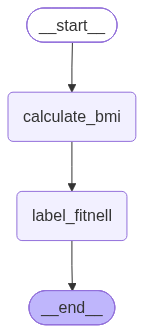

In [38]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())